# ANN based classification with pytorch

In this notebook, we will work through setting up a model and running a classification fit on the weather dataset. For more details, see
https://zenodo.org/records/5071376

In [1]:
import pandas as pd

data = pd.read_csv("https://zenodo.org/record/5071376/files/weather_prediction_dataset_light.csv?download=1")

In [2]:
data.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max',
       'DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure',
       'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine',
       'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max',
       'DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
       'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
       'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover',
       'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
       'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation',
       'DUSSELDORF_sunshine', 'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min',
       'DUSSELDORF_temp_max', 'HEATHROW_cloud_cover', 'HEATHROW_humidity',
       'HEATHROW_pressure', 'HEATHROW_global_radiation',
       'HEATH

In [3]:
data.shape

(3654, 91)

In [4]:
nr_rows = 3*365

# limit the dataset to 3 years
X_data = data.loc[:nr_rows]

# drop date and month to avoid fitting it
X_data = X_data.drop(columns=['DATE', 'MONTH'])

## Creating a Classification Dataset

In [5]:
import numpy as np

y_data_ = data.loc[1:(nr_rows+1)]["BASEL_sunshine"]
y_data = (y_data_ > 5).astype(np.int32)

In [6]:
X_data.describe()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,DE_BILT_cloud_cover,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,...,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,5.540146,0.754991,1.017604,1.280265,0.259735,4.527646,11.230201,7.281478,15.628285,5.693431,...,-4.505839,-6.768796,-2.236131,0.798157,1.016250,1.287162,0.228285,12.228011,8.067427,16.389964
std,2.338527,0.102911,0.008037,0.944279,0.507003,4.423591,6.707113,5.946344,7.992811,1.928634,...,6.447168,6.620462,6.416290,0.104863,0.008792,0.912311,0.458911,5.776617,5.142372,6.945459
min,0.000000,0.380000,0.988200,0.060000,0.000000,0.000000,-8.000000,-13.000000,-5.500000,0.000000,...,-23.500000,-28.700000,-21.000000,0.480000,0.976200,0.050000,0.000000,-3.500000,-6.900000,-1.400000
25%,4.000000,0.680000,1.013000,0.480000,0.000000,0.400000,6.600000,3.300000,9.500000,5.000000,...,-8.825000,-11.300000,-6.500000,0.730000,1.011300,0.490000,0.000000,8.200000,4.475000,11.300000
50%,6.000000,0.760000,1.017300,1.015000,0.010000,3.350000,11.300000,7.600000,15.600000,6.000000,...,-4.600000,-6.650000,-2.450000,0.810000,1.016650,1.110000,0.020000,12.000000,8.400000,15.900000
75%,7.000000,0.830000,1.022300,1.982500,0.300000,7.825000,16.600000,11.800000,22.000000,7.000000,...,0.300000,-1.500000,2.200000,0.880000,1.021500,1.970000,0.240000,16.800000,12.000000,21.500000
max,8.000000,0.980000,1.040600,3.520000,4.110000,15.300000,26.800000,19.200000,34.500000,8.000000,...,13.800000,7.000000,14.100000,0.990000,1.038300,3.560000,3.800000,26.500000,21.200000,35.300000


In [7]:
y_data.value_counts()

BASEL_sunshine
0    668
1    428
Name: count, dtype: int64

`y_data` can now be used as a binary label, i.e. if tomorrow will be a sunny day in BASEL or not or whether you can have a BBQ with friends tomorrow.

In this way, we can now use `X_data` and `y_data` for a classification task now.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=1234)

In [9]:
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=.5,random_state=1234)

In [10]:
print(X_train.shape, X_train.dtypes)
print(y_train.shape, y_train.dtypes)


(767, 89) BASEL_cloud_cover           int64
BASEL_humidity            float64
BASEL_pressure            float64
BASEL_global_radiation    float64
BASEL_precipitation       float64
                           ...   
TOURS_global_radiation    float64
TOURS_precipitation       float64
TOURS_temp_mean           float64
TOURS_temp_min            float64
TOURS_temp_max            float64
Length: 89, dtype: object
(767,) int32


In [11]:
import torch
import time

class mlp_classification_model(torch.nn.Module):

    def __init__(self, in_shape = X_data.shape[-1], num_classes=2):
        super().__init__()
        #for more complicated models, this constructor will be rather complicated
        self.hidden0 = torch.nn.Linear(in_features=in_shape, out_features=100)
        self.relu0 = torch.nn.ReLU()

        self.hidden1 = torch.nn.Linear(in_features=100, out_features=50)
        self.relu1 = torch.nn.ReLU()

        self.hidden2 = torch.nn.Linear(in_features=50, out_features=num_classes)
        self.outactivation = torch.nn.Softmax()

    def forward(self, x):
        """ forward pass of our model, using x as the input data. the output should be the prediction y_hat. """

        h = self.hidden0(x)
        h_ = self.relu0(h)
        
        output_ = self.hidden1(h_)
        output = self.relu1(output_)

        y_hat = self.hidden2(output)
        #logit_output = self.outactivation(y_hat)
        return y_hat#logit_output


In [12]:
model = mlp_classification_model()

In [13]:
model

mlp_classification_model(
  (hidden0): Linear(in_features=89, out_features=100, bias=True)
  (relu0): ReLU()
  (hidden1): Linear(in_features=100, out_features=50, bias=True)
  (relu1): ReLU()
  (hidden2): Linear(in_features=50, out_features=2, bias=True)
  (outactivation): Softmax(dim=None)
)

## How large is our model

When ML researchers or engineers talk about their models, they often use a metric to compare models casually. This metric is the number of parameters. Write code that counts the number of parameters. Use the `nn.Module` API documentation [here](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module) to find an appropriate which provides you with an iterator over all parameters. 

In [14]:
num_parameters = sum(param.numel() for param in model.parameters())
print(f"MLP model has {num_parameters} parameters ({num_parameters*4./(1024.*1024.):02.1f} MiB)")

MLP model has 14152 parameters (0.1 MiB)


## The training loop

In [15]:
optimizer = torch.optim.Adam(model.parameters())
loss_fn = torch.nn.CrossEntropyLoss()

In [16]:
torch_X_train = torch.from_numpy(X_train.to_numpy())
torch_y_train = torch.from_numpy(y_train.to_numpy())

torch_X_test = torch.from_numpy(X_test.to_numpy())
torch_y_test = torch.from_numpy(y_test.to_numpy())

stacked_train = torch.utils.data.StackDataset(X=torch_X_train, y=torch_y_train)


In [17]:
batch_size = 32
max_nepochs = 200
train_loader = torch.utils.data.DataLoader(stacked_train, batch_size = batch_size)
nsteps = len(train_loader)
train_bce, train_acc = torch.zeros((nsteps,)), torch.zeros((nsteps,))
history = {
    "train_bce": [],
    "train_acc": []
}

for epoch in range(max_nepochs):
    start = time.time()
    for stepi, batch in enumerate(train_loader):

        # load data
        X, y = batch["X"].float(), batch["y"].float()

        # forward pass
        y_logit = model(X)
        
        # compute loss
        loss = loss_fn(y_logit.float(),
                       y.long().view(-1))
        
        # obtain index of highest probility class
        y_hat = torch.argmax(y_logit, dim=-1)
        accuracy = (y_hat.detach() == y.detach()).sum(dim=-1)/X.shape[0]

        # perform backprop
        loss.backward()
        # update weights
        optimizer.step()
        # set gradients to 0 for next step
        optimizer.zero_grad()

        train_bce[stepi] = loss.item()
        train_acc[stepi] = accuracy.item()

    end = time.time()
    delta_seconds = end - start
    if (epoch+1) % 5 == 0:
        print(f"{epoch+1:03.0f}/{max_nepochs:03.0f}: {delta_seconds:02.4f}s loss={train_bce.mean():03.4f} acc={train_acc.mean():03.4f} {delta_seconds*1000./(nsteps):3.1f} ms/step")

    history["train_bce"].append(train_bce.numpy().mean())
    history["train_acc"].append(train_acc.numpy().mean())


005/200: 0.0284s loss=0.5204 acc=0.7458 1.2 ms/step
010/200: 0.0238s loss=0.4840 acc=0.7693 1.0 ms/step


015/200: 0.0339s loss=0.4511 acc=0.7811 1.4 ms/step
020/200: 0.0241s loss=0.4092 acc=0.8045 1.0 ms/step


025/200: 0.0261s loss=0.3661 acc=0.8318 1.1 ms/step
030/200: 0.0284s loss=0.3241 acc=0.8644 1.2 ms/step


035/200: 0.0291s loss=0.2871 acc=0.8697 1.2 ms/step
040/200: 0.0246s loss=0.2642 acc=0.8866 1.0 ms/step


045/200: 0.0277s loss=0.2259 acc=0.9022 1.2 ms/step
050/200: 0.0244s loss=0.2263 acc=0.9023 1.0 ms/step


...

155/200: 0.0264s loss=0.0090 acc=1.0000 1.1 ms/step
160/200: 0.0250s loss=0.0051 acc=1.0000 1.0 ms/step


165/200: 0.0268s loss=0.0042 acc=1.0000 1.1 ms/step
170/200: 0.0249s loss=0.0036 acc=1.0000 1.0 ms/step


175/200: 0.0267s loss=0.0031 acc=1.0000 1.1 ms/step
180/200: 0.0249s loss=0.0027 acc=1.0000 1.0 ms/step


185/200: 0.0270s loss=0.0024 acc=1.0000 1.1 ms/step
190/200: 0.0247s loss=0.0022 acc=1.0000 1.0 ms/step


195/200: 0.0273s loss=0.0020 acc=1.0000 1.1 ms/step
200/200: 0.0249s loss=0.0018 acc=1.0000 1.0 ms/step


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_history(history, metrics):
    """ plot the history of our weather prediction model """

    history_df = pd.DataFrame.from_dict(history)
    data = history_df[metrics]

    fig, ax = plt.subplots()
    sns.lineplot(data=data, ax=ax)
    ax.set_xlabel("epochs")
    ax.set_ylabel("metric")

    return fig, ax


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='epochs', ylabel='metric'>)

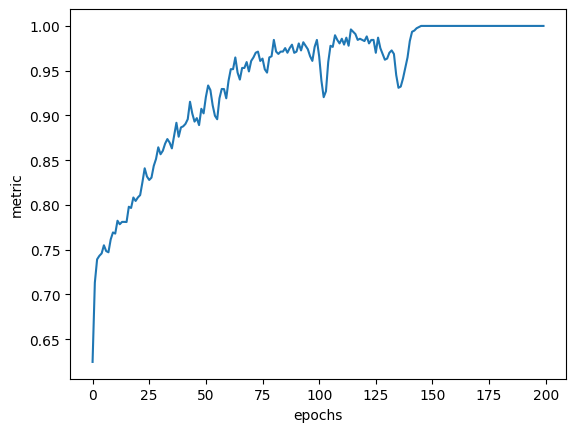

In [19]:
plot_history(history, "train_acc")

In [20]:
y_train_pred = model(torch_X_train.float()).argmax(-1)
y_test_pred = model(torch_X_test.float()).argmax(-1)

## Exercise 1: confusion matrices 

Use the model from above and plot a confusion matrix using 

a) the training set or
b) the test set.

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_predictions(y_pred, y_true, title, labels=[0,1]):
    """ visualize a comparison of predicted versus true values """

    ...


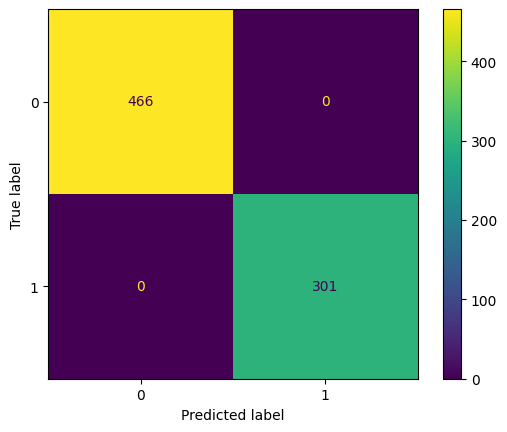

In [22]:
plot_predictions(y_train_pred.detach().numpy(),
                 y_train.to_numpy(),
                 title="predictions on the test set")

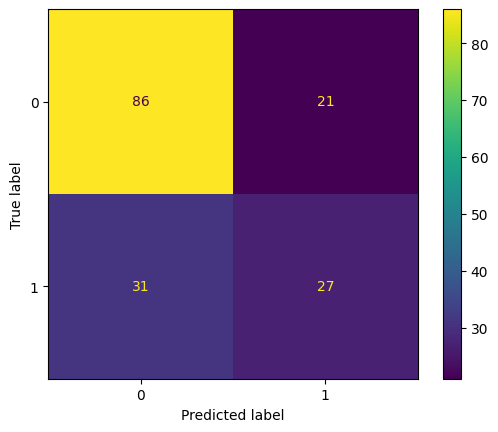

In [23]:
plot_predictions(y_test_pred.detach().numpy(),
                 y_test.to_numpy(),
                 title="predictions on the test set")

## Exercise 2: Record metrics on the validation set

Take the model training loop from above and add recording of metrics from the test set. As you will recall from the regression case, this will help you in judging if your model is overfitting or not. 

In [24]:
model2 = mlp_classification_model()
optimizer2 = torch.optim.Adam(model2.parameters())
loss_fn2 = torch.nn.CrossEntropyLoss()

In [25]:
torch_X_val = torch.from_numpy(X_val.to_numpy())
torch_y_val = torch.from_numpy(y_val.to_numpy())

stacked_val = torch.utils.data.StackDataset(X=torch_X_val, y=torch_y_val)
val_loader = torch.utils.data.DataLoader(stacked_val, batch_size = batch_size)

print(torch_X_val.shape, torch_y_val.shape)

torch.Size([164, 89]) torch.Size([164])


In [26]:
def train(model, crit, opt, train_loader, val_loader, batch_size=32,max_nepochs=200):

    nsteps = len(train_loader)
    nsteps_val = len(val_loader)
    train_loss, train_acc = torch.zeros((nsteps,)), torch.zeros((nsteps,))
    val_loss, val_acc = torch.zeros((nsteps_val,)), torch.zeros((nsteps_val,))
    
    history2 = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    
    for epoch in range(max_nepochs):
        start = time.time()
        model.train()
        for stepi, batch in enumerate(train_loader):
            
            # load data
            X, y = batch["X"].float(), batch["y"].float()
            
            # forward pass
            y_logit = model(X)
            
            # compute loss
            loss = crit(y_logit.float(), y.long().view(-1))
    
            # obtain index of highest probility class
            y_hat = torch.argmax(y_logit, dim=-1)
            accuracy = (y_hat.detach() == y.detach()).sum(dim=-1)/X.shape[0]
            
            # perform backprop
            loss.backward()
            # update weights
            opt.step()
            # set gradients to 0 for next step
            opt.zero_grad()
    
            train_loss[stepi] = loss.item()
            train_acc[stepi] = accuracy.item()
    
        end = time.time()
        delta_seconds = end - start
    
        history2["train_loss"].append(train_loss.mean().item())
        history2["train_acc" ].append(train_acc.mean().item())
        model.eval()
        with torch.no_grad():
            
            for vstepi, vbatch in enumerate(val_loader):
                # insert code here
                ...

            history2["val_loss"].append(val_loss.mean().item())
            history2["val_acc"].append(val_acc.mean().item())
            
        if (epoch+1) % 5 == 0:
            print(f"{epoch+1:03.0f}/{max_nepochs:03.0f}: {delta_seconds:02.4f} "
                  f"loss={train_loss.mean():03.4f} acc={train_acc.mean():03.4f} "
                  f"vloss={val_loss.mean():03.4f} vacc={val_acc.mean():03.4f} "
                  f"{delta_seconds*1000./(nsteps):3.1f} ms/step")

    return history2

In [27]:
history2 = train(model2, loss_fn2, optimizer2, train_loader, val_loader)

005/200: 0.0265 loss=0.5164 acc=0.7471 vloss=0.5060 vacc=0.7500 1.1 ms/step


010/200: 0.0237 loss=0.4885 acc=0.7654 vloss=0.4971 vacc=0.7656 1.0 ms/step


015/200: 0.0244 loss=0.4619 acc=0.7797 vloss=0.4994 vacc=0.7344 1.0 ms/step


020/200: 0.0241 loss=0.4348 acc=0.7954 vloss=0.5003 vacc=0.7240 1.0 ms/step


025/200: 0.0267 loss=0.4054 acc=0.8097 vloss=0.5329 vacc=0.7396 1.1 ms/step


...

180/200: 0.0251 loss=0.0638 acc=0.9764 vloss=2.1580 vacc=0.7031 1.0 ms/step


185/200: 0.0270 loss=0.0424 acc=0.9869 vloss=2.0600 vacc=0.6771 1.1 ms/step


190/200: 0.0251 loss=0.0805 acc=0.9765 vloss=2.0541 vacc=0.6875 1.0 ms/step


195/200: 0.0251 loss=0.0522 acc=0.9791 vloss=1.8958 vacc=0.6771 1.0 ms/step


200/200: 0.0273 loss=0.0581 acc=0.9804 vloss=2.3620 vacc=0.6406 1.1 ms/step


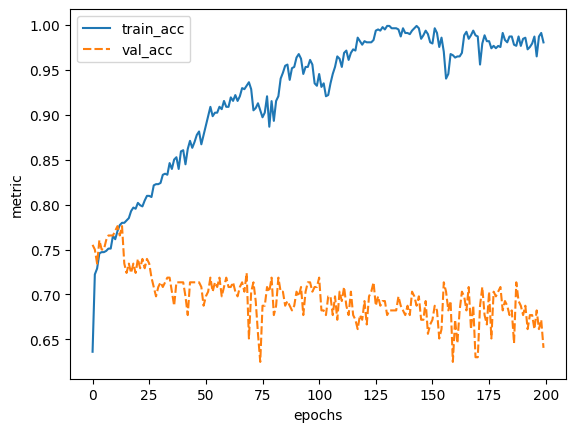

In [28]:
fig, ax = plot_history(history2, ["train_acc", "val_acc"])

The validation stops decreasing very early (around epoch 10). After that, the network apparently goes into **overfitting** (training accuracy increases while the validation accuracy is constant, fluctuates or decreases). 

## Exercise: Try Regularisation

In the following, try at least one regularisation technique that you learned in the lecture. Check if the training behavior changes.

## Exercise 3: Implicit Regularisation

Rewrite the model from above and insert one `Dropout` layer after each hidden layer. Make the dropout rate configurable by introducing a constructor parameter `dropout_rate` which sets the dropout rate for all layers. At which drop out rate does overfitting cease to be observable? 

In [39]:
class dropout_classification_model(torch.nn.Module):

    def __init__(self, in_shape = X_data.shape[-1], num_classes=2, do_rate=.3):
        super().__init__()
        . . . 
        

    def forward(self, x):
        """ forward pass of our model, using x as the input data. the output should be the prediction y_hat. """
        . . .

In [40]:
model3 = dropout_classification_model(do_rate=0.5)
optimizer3 = torch.optim.Adam(model3.parameters())
loss_fn3 = torch.nn.CrossEntropyLoss()

In [41]:
batch_size=32
nepochs=100
train_loader = torch.utils.data.DataLoader(stacked_train, batch_size = batch_size)
val_loader = torch.utils.data.DataLoader(stacked_val, batch_size = batch_size)

history3 = train(model3, loss_fn3, optimizer3, train_loader, val_loader, batch_size=batch_size, max_nepochs=nepochs)

005/100: 0.0263 loss=0.6083 acc=0.6584 vloss=0.5596 vacc=0.7760 1.1 ms/step
010/100: 0.0259 loss=0.5741 acc=0.6923 vloss=0.5376 vacc=0.7604 1.1 ms/step


015/100: 0.0269 loss=0.5573 acc=0.7262 vloss=0.5290 vacc=0.7448 1.1 ms/step
020/100: 0.0401 loss=0.5330 acc=0.7392 vloss=0.5194 vacc=0.7708 1.7 ms/step


025/100: 0.0262 loss=0.5242 acc=0.7431 vloss=0.5137 vacc=0.7031 1.1 ms/step
030/100: 0.0262 loss=0.5156 acc=0.7367 vloss=0.5261 vacc=0.7760 1.1 ms/step


035/100: 0.0277 loss=0.5116 acc=0.7523 vloss=0.5078 vacc=0.7760 1.2 ms/step
040/100: 0.0271 loss=0.5019 acc=0.7549 vloss=0.5049 vacc=0.7760 1.1 ms/step


045/100: 0.0269 loss=0.4805 acc=0.7784 vloss=0.5254 vacc=0.7708 1.1 ms/step
050/100: 0.0291 loss=0.5119 acc=0.7667 vloss=0.5075 vacc=0.7760 1.2 ms/step


055/100: 0.0270 loss=0.4725 acc=0.7824 vloss=0.5017 vacc=0.7812 1.1 ms/step
060/100: 0.0271 loss=0.4824 acc=0.7667 vloss=0.5177 vacc=0.7656 1.1 ms/step


065/100: 0.0270 loss=0.4649 acc=0.7771 vloss=0.5272 vacc=0.7812 1.1 ms/step
070/100: 0.0273 loss=0.4714 acc=0.7602 vloss=0.5456 vacc=0.7760 1.1 ms/step


075/100: 0.0270 loss=0.4405 acc=0.7744 vloss=0.5369 vacc=0.7708 1.1 ms/step
080/100: 0.0273 loss=0.4518 acc=0.7744 vloss=0.5741 vacc=0.7812 1.1 ms/step


085/100: 0.0274 loss=0.4486 acc=0.7913 vloss=0.5736 vacc=0.7812 1.1 ms/step
090/100: 0.0286 loss=0.4490 acc=0.7784 vloss=0.5225 vacc=0.7865 1.2 ms/step


095/100: 0.0277 loss=0.4514 acc=0.7901 vloss=0.5707 vacc=0.7760 1.2 ms/step
100/100: 0.0277 loss=0.4284 acc=0.7758 vloss=0.5873 vacc=0.7188 1.2 ms/step


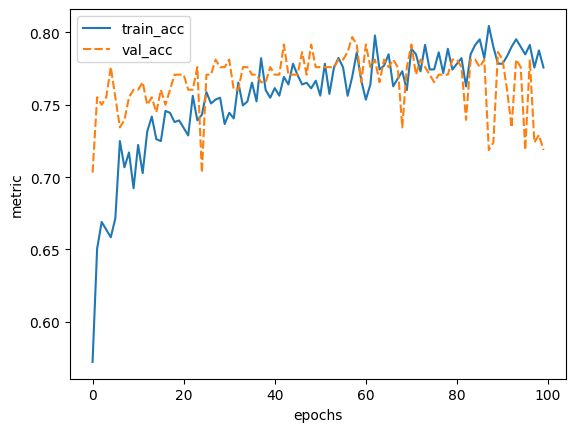

In [42]:
fig, ax = plot_history(history3, ["train_acc", "val_acc"])